# Integer programming model for total b-chromatic colouring

In [1]:
import sys
#sys.path.insert(1, "../")
#from b_chromatic_utils import get_m_degree #we need the index m-degree
import pulp as pl
import networkx as nx

## Computing the total $m$-degree

Total degree of vertex $u\in V(G)$ is defined as $d_t(u)=d(u)$

Total degree of edge $(u,v)\in E(G)$ is defined as $d_t(u,v)=d(u)+d(v)$

In [2]:
def get_total_m_degree(G):
    number_of_objects = G.number_of_nodes()+G.number_of_edges()
    X = [0 for _ in range(0, number_of_objects+1)]
    Z = [0 for _ in range(0, number_of_objects+1)]
    max_j = 0
    for u in G.nodes(): X[2*G.degree(u)] += 1
    for u,v in G.edges(): X[G.degree(u)+G.degree(v)] += 1
    for j in range(number_of_objects-1, 0, -1): Z[j] = Z[j+1] + X[j]
    for j in range(1, number_of_objects):
        if Z[j-1] >= j:
            max_j = j
    return max_j

## Random $d$-regular graph

## IP model

For now, the model will be a combination of the vertex and edge b-chromatic colouring models

### Variables

$w_j=1$ if colour $j\in \{1,\dots, m\}$ is used; otherwise $w_j=0$ where $m=m_t(T)$

In [3]:
def get_colour_var(C):
    """C: Set of colours"""
    w_vars = {j:pl.LpVariable(cat=pl.LpBinary,name="w_{0}".format(j)) 
                        for j in C}
    return w_vars

$x_{uj}=1$ if vertex $v$ has colour $j$ assigned to it; otherwise $x_{uj}=0$

In [4]:
def get_vertex_colour_var(V, C):
    """ V: Vertices\n
        C: set of colours"""
    x_vars = {(u,j):pl.LpVariable(cat=pl.LpBinary,name="x_{0}_{1}".format(u,j))
          for u in V for j in C}
    return x_vars

$y_{ej}=1$ if edge $e$ is assigned colour $j$; otherwise $y_{ej}=0$

In [6]:
def get_edge_colour_var(E, C):
    """E: Edges\n
       C: set of colours"""
    y_vars = {(u,v,j):pl.LpVariable(cat=pl.LpBinary,name="y_{0}_{1}_{2}".format(u,v,j))
            for u,v in E for j in C}
    return y_vars

$t_{uj}=1$ if vertex $v$ is a total b-chromatic vertex of colour $j$; otherwise $t_{uj}=0$

In [7]:
def get_b_chromatic_vertex_var(V, C):
    """ V: vertices\n
        C: set of colours"""
    t_vars = {(u,j):pl.LpVariable(cat=pl.LpBinary,name="t_{0}_{1}".format(u,j))
            for u in V for j in C}
    return t_vars

$z_{ej}=1$ if edge $e$ is a total b-chromatic edge of colour $j$; otherwise $z_{ej}=0$

In [8]:
def get_b_chromatic_edge_var(E, C):
    """ E: edges\n
        C: set of colours"""
    z_vars = {(u,v,j):pl.LpVariable(cat=pl.LpBinary,name="z_{0}_{1}_{2}".format(u,v,j))
            for u,v in E for j in C}
    return z_vars

### Constraints

#### One colour per object

$\sum_{j\in C}x_{vj}=1$ for every $v\in V$

In [9]:
def add_one_colour_per_vertex_constraint(b_chr_total_model, x_vars, V, C):
    one_colour_per_vertex = {u:b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e = pl.lpSum(x_vars[u,j] for j in C),
            sense=pl.LpConstraintEQ,
            rhs=1,
            name="one_colour_vertex_{0}".format(u)
        )
    )
    for u in V}
    return b_chr_total_model

$\sum_{j\in C}y_{ej}=1$ for every $e\in E$

In [10]:
def add_one_colour_per_edge_constraint(b_chr_total_model, y_vars, E, C):
    one_colour_per_edge = {(u,v):b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e = pl.lpSum(y_vars[u,v,j] for j in C),
            sense=pl.LpConstraintEQ,
            rhs=1,
            name="one_colour_edge_{0}_{1}".format(u,v)
        )
    )
    for u, v in E}
    return b_chr_total_model

#### Different colour per adjacent objects

$x_{uj}+x_{vj}\leq 1$ for every pair of adjacent vertices $(u,v)\in E$ and every colour $j\in \{1,\dots, m\}$

In [11]:
def add_different_colour_adj_vertices_constraint(b_chr_total_model, x_vars, E, C):
    different_colour_adj_vertices = {(u,v,j):b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e = x_vars[u,j]+x_vars[v,j],
            sense=pl.LpConstraintLE,
            rhs=1,
            name="different_colour_adj_vertices_{0}_{1}_{2}".format(u,v,j)
        )
    )
    for u,v in E for j in C}
    return b_chr_total_model

$y_{ej}+y_{fj}\leq 1$ for every pair of adjacent edges $e,j\in E$, i.e., $e\cap f\neq \empty$, and every colour $j\in \{1,\dots, m\}$

In [12]:
def add_different_colour_adj_edges_constraint(b_chr_total_model, y_vars, E, C):
    different_colour_adj_edges = {(u1,v1,u2,v2,j):b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e = y_vars[u1,v1,j]+y_vars[u2,v2,j],
            sense=pl.LpConstraintLE,
            rhs=1,
            name="different_colour_adj_vertices_{0}_{1}_{2}_{3}_{4}".format(u1,v1,u2,v2,j)
        )
    )
    for i, (u1,v1) in enumerate(E) for u2,v2 in E[i+1:] 
    for j in C
    if u1 == u2 or u1 == v2 or v1 == u2 or v1 == v2}
    return b_chr_total_model

$x_{uj}+y_{ej}\leq 1$ for every vertex $u$ and edge $e$ where $u\in e$, and every colour $j\in \{1,\dots, m\}$

In [13]:
def add_different_colour_vertex_incident_edge_constraint(b_chr_total_model, x_vars, y_vars, V, E, C):
    different_colour_vertex_incident_edge = {(w,u,v,j):b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e = x_vars[w,j]+y_vars[u,v,j],
            sense=pl.LpConstraintLE,
            rhs=1,
            name="different_colour_vertex_{0}_incident_edge_{1}_{2}_colour_{3}".format(w,u,v,j)
        )
    )
    for w in V for u,v in E for j in C}
    return b_chr_total_model

#### $w_j=1$ if and only if colour $j$ was assigned to any edge or vertex

$(\Rightarrow)$

$x_{uj} \leq w_j$ for every vertex $v\in V$ and for every colour $j\in \{1,\dots, m\}$

In [14]:
def add_colour_assigned_to_some_vertex_if_constraint(b_chr_total_model, x_vars, w_vars, V, C):
    colour_assigned_to_some_vertex_if = {(u,j):b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e=x_vars[u,j]-w_vars[j],
            sense=pl.LpConstraintLE,
            rhs=0,
            name="colour_{0}_assigned_to_some_vertex_{1}_if".format(u,j)
        )
    )
    for u in V for j in C}
    return b_chr_total_model

$y_{ej}\leq w_j$ for every $e\in E$ and every colour $j\in \{1,\dots, m\}$ 

In [15]:
def add_colour_assigned_to_some_edge_if_constraint(b_chr_total_model, y_vars, w_vars, E, C):
    colour_assigned_to_some_edge_if = {(u,v,j):b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e=y_vars[u,v,j]-w_vars[j],
            sense=pl.LpConstraintLE,
            rhs=0,
            name="colour_{0}_assigned_to_some_edge_{1}_{2}_if".format(u,v,j)
        )
    )
    for u,v in E for j in C}
    return b_chr_total_model

##### Alternative version

$(\Rightarrow)$

$x_{uj}+y_{ej}\leq w_j$ for every vertex $v\in V$ and every edge $e\in E$ such that $u\not \in e$, and for every colour $j\in \{1,\dots, m\}$

In [16]:
def add_colour_assigned_to_some_vertex_edge_if_constraint(b_chr_total_model, x_vars, y_vars, w_vars, V, E, C):
    colour_assigned_to_some_vertex_edge_if = {(x, u, v, j): b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e=x_vars[x,j]+y_vars[u,v,j]-w_vars[j],
            sense=pl.LpConstraintLE,
            rhs=0,
            name="colour_{0}_assigned_to_vertex_{1}_or_edge_{2}_{3}".format(x,u,v,j)
        )
    )
    for x in V for u, v in E for j in C if x != u and x != v}
    return b_chr_total_model

$(\Leftarrow)$

$\sum_{v\in V}x_{vj}\geq w_j$ for every $j\in \{1,\dots, m\}$

In [17]:
def add_colour_assinged_to_some_vertex_onlyif_constraint(b_chr_total_model, x_vars, w_vars, V, C):
    colour_assinged_to_some_vertex_onlyif = {j:b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e=pl.lpSum(x_vars[u,j] for u in V)-w_vars[j],
            sense=pl.LpConstraintGE,
            rhs=0,
            name="colour_{0}_assigned_to_some_vertex_onlyif".format(j)
        )
    )
    for j in C}
    return b_chr_total_model

$\sum_{e\in E}y_{ej}\geq w_j$ for every $j\in \{1,\dots, m\}$

In [18]:
def add_colour_assinged_to_some_edge_onlyif_constraint(b_chr_total_model, y_vars, w_vars, E, C):
    colour_assinged_to_some_edge_onlyif = {j:b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e=pl.lpSum(y_vars[u,v,j] for u,v in E)-w_vars[j],
            sense=pl.LpConstraintGE,
            rhs=0,
            name="colour_{0}_assigned_to_some_edge_onlyif".format(j)
        )
    )
    for j in C}
    return b_chr_total_model

Alternative version

$(\Leftarrow)$

$\sum_{u\in V}x_{uj}+\sum_{e\in E}y_{ej}\geq w_j$ for every colour $j\in \{1,\dots, m\}$

In [19]:
def add_colour_assigned_to_some_vertex_edge_onlyif_constraint(b_chr_total_model, x_vars, y_vars,w_vars, V, E, C):
    colour_assigned_to_some_vertex_edge_onlyif = {j:b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e=pl.lpSum(x_vars[u,j] for u in V)+pl.lpSum(y_vars[u,v,j] for u,v in E)-w_vars[j],
            sense=pl.LpConstraintGE,
            rhs=0,
            name="colour_{0}_assigned_to_some_vertex_edge_onlyif".format(j)
        )
    ) for j in C}
    return b_chr_total_model

#### total b-chromatic constraints: for every colour there must be a b-chromatic vertex or edge

for every vertex $u\in V$, $t_{uj}=1$ if colour $j$ is indeed used and there is an vertex or edge adjacent or incident to $u$ of every other colour

$t_{uj}\leq 1-(w_{j'}-\sum_{v\in N(u)}x_{vj'}-\sum_{v\in N(u)}y_{(u,v)j'})$ for every vertex $u\in V$ and every pair of colours $j,j'\in \{1,\dots, m\}$, $j\neq j'$

In [20]:
def add_total_b_chromatic_vertex_colour_j_constraint(b_chr_total_model, t_vars, w_vars, x_vars, y_vars, V, E, C):
    total_b_chromatic_vertex_colour_j = {(u,j, jp): b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e = t_vars[u,j]+w_vars[jp]-pl.lpSum(x_vars[v,jp] for v in V)-pl.lpSum(y_vars[a,b,jp] for a, b in E if a == u or b == u),
            sense=pl.LpConstraintLE,
            rhs=1,
            name="total_b_chromatic_vertex_{0}_colour_{1}_adj_inc_element_colour_{2}".format(u,j,jp)
        )
    )
    for u in V for j in C for jp in C if j != jp}
    return b_chr_total_model

for every edge $e\in E$, $z_{ej}=1$ if colour $j$ is indeed used and there is an vertex or edge incident or adjacent to $e$ of every other colour

$z_{ej}\leq 1-(w_{j'}-\sum_{f\in E, e\cap f\neq \emptyset}y_{fj'}-(x_{uj'}+x_{vj'}))$ for every edge $e=(u,v)\in E$ and every pair of colours $j,j'\in \{1,\dots, m\}$, $j\neq j'$

In [225]:
def add_total_b_chromatic_edge_colour_j_constraint(b_chr_total_model, z_vars, w_vars, y_vars, x_vars, E, C):
    total_b_chromatic_edge_colour_j = {(u,v,j,jp): b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e = z_vars[u,v,j]+w_vars[jp]-pl.lpSum(y_vars[u1,v1,jp]-x_vars[u,jp]-x_vars[v,jp] for u1, v1 in E if len({u,v}.intersection({u1,v1})) <= 1),
            sense=pl.LpConstraintLE,
            rhs=1,
            name="total_b_chromatic_edge_{0}_{1}_colour_{2}_adj_inc_element_colour_{3}".format(u,v,j,jp)
        )
    )
    for u, v in E for j in C for jp in C if j != jp}
    return b_chr_total_model

#### Alternative version

$t_{uj}+z_{ej}\leq 1 - (w_{j'}-\sum_{v\in N(u)}x_{vj'}+y_{(u,v)j'} - \sum_{f\in E, e\cap f\neq \emptyset}y_{fj'}-(x_{uj'}+x_{vj'}))$

In [ ]:
def add_total_b_chromatic_vertex_or_edge_colour_j_constraint(b_chr_total_model,z_vars,t_vars,x_vars,y_vars, V, E, C):
    total_b_chromatic_vertex_or_edge_colour_j = {(x, u, v, j, jp):b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e=
        )
    )
    for x in V for u,v in E for j in C for jp in C if j != jp}

there is a total b-chromatic vertex or edge for every colour used

$\sum_{u\in V}t_{uj}+\sum_{e\in E}z_{ej}\geq w_j$ for every colour $j\in \{1,\dots, m\}

In [226]:
def add_there_is_total_b_chromatic_element_for_every_colour_constraint(b_chr_total_model, t_vars, z_vars, w_vars, E, C):
    there_is_total_b_chromatic_element_for_every_colour = {j:b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e=pl.lpSum(t_vars[u,j] for u in V)+pl.lpSum(z_vars[u,v,j] for u,v in E)-w_vars[j],
            sense=pl.LpConstraintGE,
            rhs=0,
            name="there_is_total_b_chromatic_element_for_colour_{0}".format(j)
        )
    ) 
    for j in C}
    return b_chr_total_model

#### Use all colours sequentially
$w_j\leq w_{j'}$ for all colours $j,j'\in \{1,\dots, m\},j'<j$

In [227]:
def add_use_all_colours_sequentially_constraint(b_chr_total_model, w_vars, C):
    use_all_colours_sequentially = {(j,jp):b_chr_total_model.addConstraint(
        pl.LpConstraint(
            e=w_vars[j]-w_vars[jp],
            sense=pl.LpConstraintLE,
            rhs=0,
            name="use_colour_{0}_before_{1}".format(j,jp)
        )
    )
    for j in C for jp in C if jp < j}
    return b_chr_total_model

### Objective function

$\max \sum_{j\in C}w_j$

In [195]:
def set_objective_function(model, sense, obj_vars, S):
    total_b_chromatic_number = pl.lpSum(obj_vars[j] for j in S)
    model.sense = sense
    model.setObjective(total_b_chromatic_number)
    return model

## Tests

## Generating the model

### Random graph

In [196]:
G = nx.random_regular_graph(d=3,n=10)

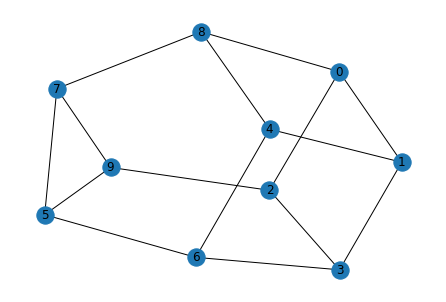

In [197]:
nx.draw(G, with_labels=True)

In [338]:
b_chr_total_model = pl.LpProblem(name="b-chromatic-total-model")
n = G.number_of_nodes()#number of vertices
m = G.number_of_edges()
V = list(G.nodes)
E = list(G.edges)
m =  get_total_m_degree(G)#number of colours
C = range(m)
print("Total m-degree: {}".format(m))

Total m-degree: 7


### Adding variables

In [339]:
w_vars = get_colour_var(C)
x_vars = get_vertex_colour_var(V, C)
y_vars = get_edge_colour_var(E, C)
t_vars = get_b_chromatic_vertex_var(V, C)
z_vars = get_b_chromatic_edge_var(E, C)

### Adding constraints

In [340]:
b_chr_total_model = add_one_colour_per_vertex_constraint(b_chr_total_model, x_vars, V, C)
b_chr_total_model = add_one_colour_per_edge_constraint(b_chr_total_model, y_vars, E, C)
b_chr_total_model = add_different_colour_adj_vertices_constraint(b_chr_total_model, x_vars, E, C)
b_chr_total_model = add_different_colour_adj_edges_constraint(b_chr_total_model, y_vars, E, C)
b_chr_total_model = add_different_colour_vertex_incident_edge_constraint(b_chr_total_model, x_vars, y_vars, V, E, C)

b_chr_total_model = add_colour_assigned_to_some_vertex_edge_if_constraint(b_chr_total_model, x_vars, y_vars, w_vars, V, E, C)
b_chr_total_model = add_colour_assigned_to_some_vertex_edge_onlyif_constraint(b_chr_total_model, x_vars, y_vars, w_vars, V, E, C)
#b_chr_total_model = add_colour_assigned_to_some_vertex_if_constraint(b_chr_total_model, x_vars, w_vars, V, C)
#b_chr_total_model = add_colour_assigned_to_some_edge_if_constraint(b_chr_total_model, y_vars, w_vars, E, C)
#b_chr_total_model = add_colour_assinged_to_some_vertex_onlyif_constraint(b_chr_total_model, x_vars, w_vars, V, C)
#b_chr_total_model = add_colour_assinged_to_some_edge_onlyif_constraint(b_chr_total_model, y_vars, w_vars, E, C)

b_chr_total_model = add_total_b_chromatic_vertex_colour_j_constraint(b_chr_total_model, t_vars, w_vars, x_vars, y_vars, V, E, C)
b_chr_total_model = add_total_b_chromatic_edge_colour_j_constraint(b_chr_total_model, z_vars, w_vars, y_vars, x_vars, E, C)
b_chr_total_model = add_there_is_total_b_chromatic_element_for_every_colour_constraint(b_chr_total_model, t_vars, z_vars, w_vars, E, C)
b_chr_total_model = add_use_all_colours_sequentially_constraint(b_chr_total_model,w_vars, C)
b_chr_total_model = set_objective_function(b_chr_total_model, pl.LpMaximize, w_vars, C)

In [341]:
b_chr_total_model.solve(pl.PULP_CBC_CMD(msg=1))

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /opt/homebrew/Caskroom/miniforge/base/envs/.tests/lib/python3.10/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/ry/3v8_xnw15pd9mvfwjp4s44z80000gn/T/c41adf52c5924efba66cb9c30e989124-pulp.mps max timeMode elapsed branch printingOptions all solution /var/folders/ry/3v8_xnw15pd9mvfwjp4s44z80000gn/T/c41adf52c5924efba66cb9c30e989124-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 3320 COLUMNS
At line 27513 RHS
At line 30829 BOUNDS
At line 31187 ENDATA
Problem MODEL has 3315 rows, 357 columns and 23471 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Problem is infeasible - 0.04 seconds
Option for printingOptions changed from normal to all
Total time (CPU seconds):       0.05   (Wallclock seconds):       0.06



-1

#### Getting the colouring

In [297]:
def get_colouring_from_model(V, E, x_vars, y_vars):
    f = {}
    for u in V:
        for c in C:
            if x_vars[u,c].value() == 1.0:
                f[u] = c
    for u, v in E:
        for c in C:
            if y_vars[u,v,c].value() == 1.0:
                f[(u,v)] = c
    return f

#### Total proper colouring check function

In [294]:
def is_a_proper_total_colouring(G, f):
    for u, v in E:
        if f[u] == f[v]: return [(u,v), False]
        for w in G.adj[u]:
            if w != v:
                if (u,w) in f and f[(u,w)] == f[(u,v)]: return [(u,w),(u,v),False]
                elif (w,u) in f and f[(w,u)] == f[(u,v)]: return [(w,u),(u,v),False]
        for w in G.adj[v]:
            if w != u:
                if (v,w) in f and f[(v,w)] == f[(u,v)]: return [(v,w), (u,v),False]
                elif (w,v) in f and f[(w,v)] == f[(u,v)]: return [(w,v), (u,v), False]
    return True

In [313]:
f = get_colouring_from_model(V, E, x_vars, y_vars)
is_a_proper_total_colouring(G,f)

True

#### Drawing with colours on nodes and edges

In [317]:
edge_labels = {(u,v):f[u,v] for u,v in E}

TypeError: 'float' object is not subscriptable

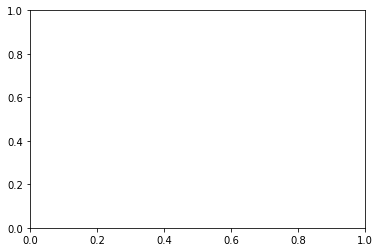

In [324]:
nx.draw_networkx_edge_labels(G, pos=.5, edge_labels=edge_labels)

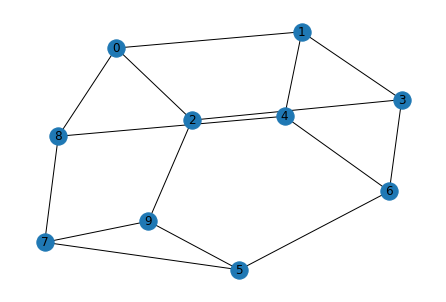

In [303]:
nx.draw(G, with_labels=True)